# Particle Filters and Sequential Monte Carlo

Particle filters approximate $p(x_t|y_{1:t})$ by weighted particles
$$
\sum_{i=1}^N w_t^{(i)} \delta(x_t-x_t^{(i)}).
$$
We illustrate importance weighting, effective sample size, and systematic resampling.

Sequential Monte Carlo approximates a filtering distribution by weighted particles. Prediction propagates dynamics, likelihood weighting incorporates the observation, and resampling combats weight collapse. Effective sample size and tracking error diagnose the tradeoff between particle count, degeneracy, and uncertainty.

The plots align latent state, observations, particle cloud, and effective sample size in time. This makes resampling events interpretable rather than presenting only a final tracking curve.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/particle-filters-smc/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/particle-filters-smc") if Path("python/particle-filters-smc").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Particle Filters and Sequential Monte Carlo**, with equations and plots designed to expose both the model and the numerical behavior.


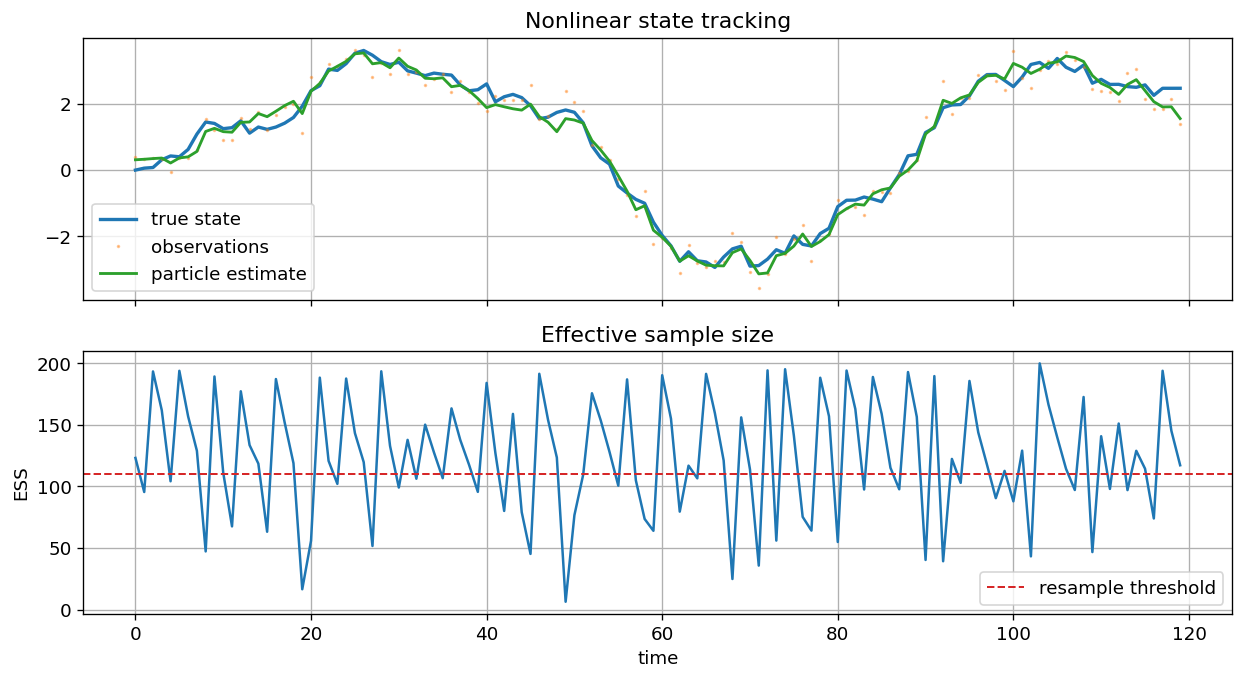

In [2]:
T = 120
q = 0.06
r = 0.12

x_true = np.zeros(T)
y = np.zeros(T)
for t in range(1, T):
    x_true[t] = 0.93 * x_true[t-1] + 0.35*np.sin(0.08*t) + rng.normal(0, np.sqrt(q))
y = x_true + rng.normal(0, np.sqrt(r), size=T)

N = 220
xp = rng.normal(0, 0.6, size=N)
w = np.ones(N) / N
est = np.zeros(T)
ess = np.zeros(T)

def systematic_resample(w):
    n = len(w)
    u0 = rng.uniform(0, 1/n)
    u = u0 + np.arange(n)/n
    cdf = np.cumsum(w)
    return np.searchsorted(cdf, u)

for t in range(T):
    if t > 0:
        xp = 0.93 * xp + 0.35*np.sin(0.08*t) + rng.normal(0, np.sqrt(q), size=N)
    ll = np.exp(-0.5*((y[t]-xp)**2)/r) / np.sqrt(2*np.pi*r)
    w *= ll
    w_sum = w.sum() + 1e-16
    w /= w_sum
    est[t] = np.sum(w * xp)
    ess[t] = 1.0 / np.sum(w**2)
    if ess[t] < 0.5 * N:
        idx = systematic_resample(w)
        xp = xp[idx]
        w.fill(1.0 / N)

fig, axes = plt.subplots(2, 1, figsize=(10.5, 5.8), sharex=True)
axes[0].plot(x_true, lw=2, label="true state")
axes[0].plot(y, ".", ms=2.2, alpha=0.4, label="observations")
axes[0].plot(est, lw=1.7, label="particle estimate")
axes[0].set_title("Nonlinear state tracking")
axes[0].legend()
axes[1].plot(ess, lw=1.5)
axes[1].axhline(0.5*N, color="tab:red", ls="--", lw=1.2, label="resample threshold")
axes[1].set_title("Effective sample size")
axes[1].set_xlabel("time")
axes[1].set_ylabel("ESS")
axes[1].legend()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- A. Doucet, N. de Freitas, N. Gordon (eds.), *Sequential Monte Carlo Methods in Practice*, Springer, 2001.
- M. S. Arulampalam et al., "A Tutorial on Particle Filters", IEEE TSP, 2002.
- P. Del Moral, *Feynman-Kac Formulae: Genealogical and Interacting Particle Systems*, Springer, 2004.
